ID           1.005685e+07
red_axis    -6.372646e-01
blue_axis    5.250921e-01
EW JADES     1.940381e+03
Name: 62, dtype: float64


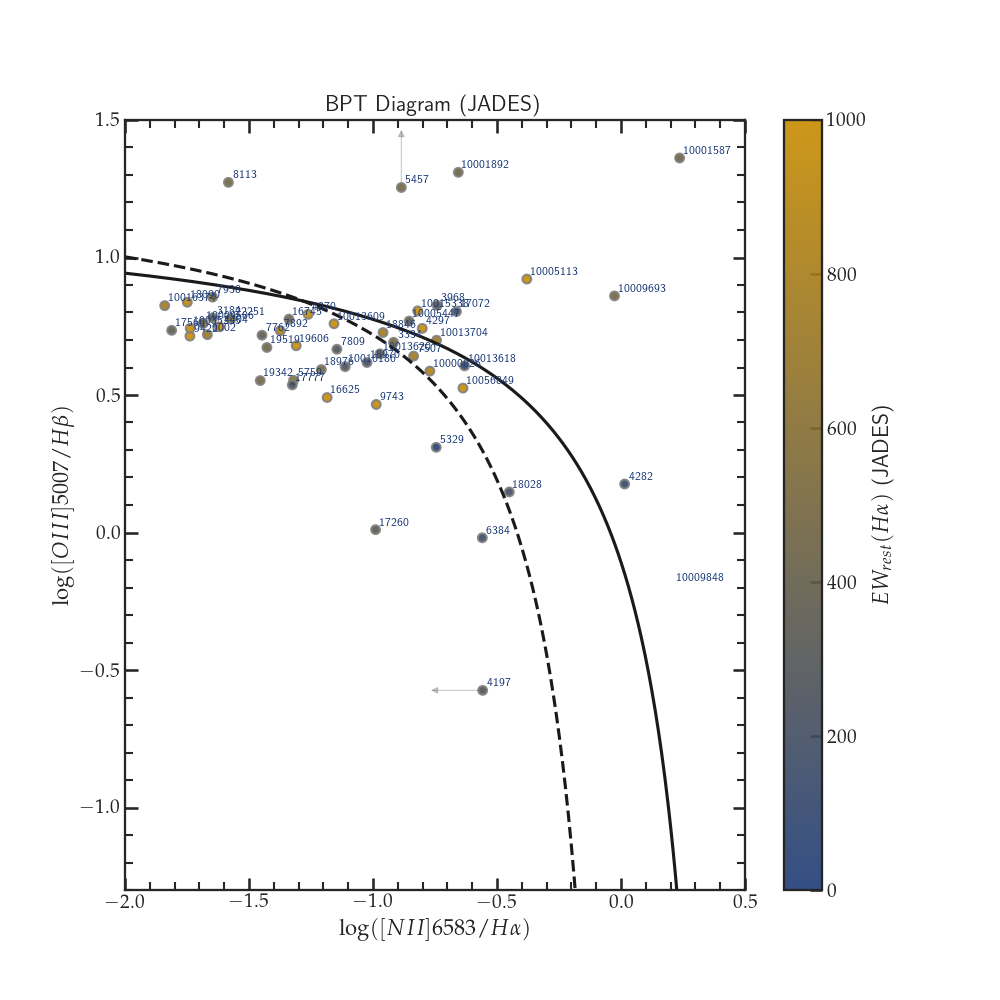

In [17]:

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

%matplotlib widget
#================= Plot Settings =================#
# Latex rendering
plt.rc('font', **{'family': 'serif', 'serif': ['palatino']}) #Helvetica
plt.rc('text', usetex=True)
plt.rc('font', weight='bold')

# --- Cosmology palette (normalized RGB) ---
COSMO_COLORS = {
    "deep_blue": (30/255, 60/255, 120/255),
    "warm_gold": (200/255, 140/255, 0/255),
    "dark_teal": (0/255, 130/255, 90/255),
    "soft_crimson": (150/255, 40/255, 40/255),
    "cool_gray": (120/255, 120/255, 120/255),
    }

sns.set_theme(
    style="ticks",
    context='talk',
    rc={
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.top": True,
        "ytick.right": True,
        "axes.grid": True,
    })

sns.set_palette([
    COSMO_COLORS["deep_blue"],
    "black",
    COSMO_COLORS["warm_gold"],
    COSMO_COLORS["cool_gray"],
    COSMO_COLORS["dark_teal"],
    COSMO_COLORS["soft_crimson"],
    ])

#General Settings
plt.rc('axes', titlesize=16)     # fontsize of the axes title
plt.rc('axes', labelsize=16)     # fontsize of the x and y labels
plt.rc('axes', linewidth=1.65 )   # width of the frame
plt.rc('xtick', labelsize=14)    # fontsize of the tick labels
plt.rc('ytick', labelsize=14)    # fontsize of the tick labels
plt.rc('legend', fontsize=12)    # legend fontsize
plt.rc('font', size=16)          # controls default text sizes


def compute_axes(source='MAST', filter='G235M', save=False, show=True):
    #================= File Reading =================#
    # Read the TSV file
    df_all = pd.read_csv('./Output_data/Line_fluxes_all_filters.tsv', sep='\t')
    equivalent_widths = pd.read_csv('./Equivalent_width_data.tsv', sep='\t')

    if source == 'MAST':
        suffix = f'MAST {filter}'
        label_prefix = 'MAST'
        save_name = './Output_data/BPT_diagram_mast.pdf'
    elif source == 'JADES':
        suffix = f'JADES {filter}'
        label_prefix = 'JADES'
        save_name = './Output_data/BPT_diagram_jades.pdf'
    

    

    # Create a sub dataframe with ID, redshift, and all columns containing the suffix
    cols = [col for col in df_all.columns if suffix in col]
    df_sub = df_all[['ID', 'redshift'] + cols].copy()
    
    
    blue_axis = np.log10(df_sub[f'Flux ([OIII]5007) {suffix}'] / df_sub[f'Flux (Hb 4861) {suffix}'])
    red_axis = np.log10(df_sub[f'Flux ([NII]6583) {suffix}'] / df_sub[f'Flux (Ha 6563) {suffix}'])

    result = {
        'ID': df_sub['ID'],
        'redshift': df_sub['redshift'],
        'blue_axis': blue_axis,
        'red_axis': red_axis,
        'red_err': df_sub[f'Flux ([NII]6583) {suffix}'] < df_sub[f'F_err([NII]6583) {suffix}'],
        'blue_err': df_sub[f'Flux (Hb 4861) {suffix}'] < df_sub[f'F_err(Hb 4861) {suffix}'],
        'EW MAST': -1*equivalent_widths['EW(Ha) MAST'],
        'EW JADES': -1*equivalent_widths['EW(Ha) JADES']
    }

    return pd.DataFrame(result)
#====================================================================#
#====================================================================#

def plt_bpt(source='JADES', arrows=True, labels=True, save=False, show=True):

    df_235 = compute_axes(source=source, filter='G235M')
    df_395 = compute_axes(source=source, filter='G395M')
    df_395H = compute_axes(source=source, filter='G395H')

    
    cols = ['blue_axis', 'red_axis', 'red_err', 'blue_err']
    
    keys = ['ID', 'redshift', f'EW {source}']
    
    # Keep only rows common to all three dataframes 
    base = (
        df_235[keys].merge(df_395[keys], on=keys, how='inner').merge(df_395H[keys], on=keys, how='inner')
    )

    # Align each dataframe to the common keys
    a = base.merge(df_235[keys + cols], on=keys, how='left')
    b = base.merge(df_395[keys + cols], on=keys, how='left')
    c = base.merge(df_395H[keys + cols], on=keys, how='left')

    # Start from common ID/redshift
    df_final = base.copy()
    
    # Priority: df_235 -> df_395 -> df_395H -> NaN
    for col in cols:
        df_final[col] = a[col].combine_first(b[col]).combine_first(c[col])


    # Kewley maximum starburst line-
    x_kewly = np.linspace(-2.0, 0.25, 500)
    x_kauff = np.linspace(-2.0, 0., 500)
    y_kewly = 0.61 / (x_kewly - 0.47) + 1.19
    y_kauff = 0.61 / (x_kauff - 0.05) + 1.3

    #=================| plot function |=================# 
    plt.figure(figsize=(10, 10))

    plt.plot(x_kewly, y_kewly, color='k', label='Kewley et al. 2001')
    plt.plot(x_kauff, y_kauff, color='k', linestyle='--', label='Kauffmann+2003')
    
    plt.xlim(-2, 0.5)
    plt.ylim(-1.3, 1.5)
    plt.xlabel(r'$\log([NII]6583/H\alpha)$')
    plt.ylabel(r'$\log([OIII]5007/H\beta)$') 
    plt.minorticks_on()
    plt.grid(False)

    xf=df_final['red_axis']
    yf=df_final['blue_axis']

    

    # Custom colormap: gray → red
    gray_red_cmap = LinearSegmentedColormap.from_list(
        'gray_red',
        [COSMO_COLORS['deep_blue'], COSMO_COLORS['warm_gold']]
    )
    
    scatter = plt.scatter(
        xf, yf,
        s=40,
        c=df_final['EW MAST'] if source == 'MAST' else df_final['EW JADES'],
        cmap=gray_red_cmap,
        edgecolor='grey',
        alpha=0.9,
        vmin=0,
        vmax=1000
    )

    cbar = plt.colorbar(scatter)
    cbar.set_label(f'$EW_{{rest}}(H\\alpha)$ ({source})')
    plt.title(f'BPT Diagram ({source})')


    if labels:
        for x, y, obj_id in zip(xf, yf, df_final['ID']):
            plt.annotate(
                str(obj_id),
                (x, y),
                textcoords="offset points",
                xytext=(3, 3),
                ha="left",
                fontsize=8,
                color=COSMO_COLORS['deep_blue']
            )

    
    
    if arrows:
        for x, y in zip(xf[df_final['red_err']], yf[df_final['red_err']] ):
            plt.annotate(
                '',
                xy=(x - 0.22, y),
                xytext=(x, y),
                arrowprops=dict(arrowstyle='-|>', color=COSMO_COLORS['cool_gray'], alpha=0.4, lw=.8, mutation_scale=10),
                va='center'
            )

        
        for x, y in zip(xf[df_final['blue_err']], yf[df_final['blue_err']] ):
            plt.annotate(
                '',
                xy=(x, y+0.22),
                xytext=(x, y),
                arrowprops=dict(arrowstyle='-|>', color=COSMO_COLORS['cool_gray'], alpha=0.4, lw=.8, mutation_scale=10),
                va='center'
            )
    
    
    if save:
        plt.savefig('bpt_v2.pdf', bbox_inches='tight')

    
    print(df_final[['ID', 'red_axis', 'blue_axis', f'EW {source}']].iloc[62])
    plt.show()

    


plt_bpt(labels=True, arrows=True, show=True)

ID           1.005685e+07
red_axis    -9.203448e-01
blue_axis    5.026994e-01
EW MAST      2.145006e+03
Name: 62, dtype: float64


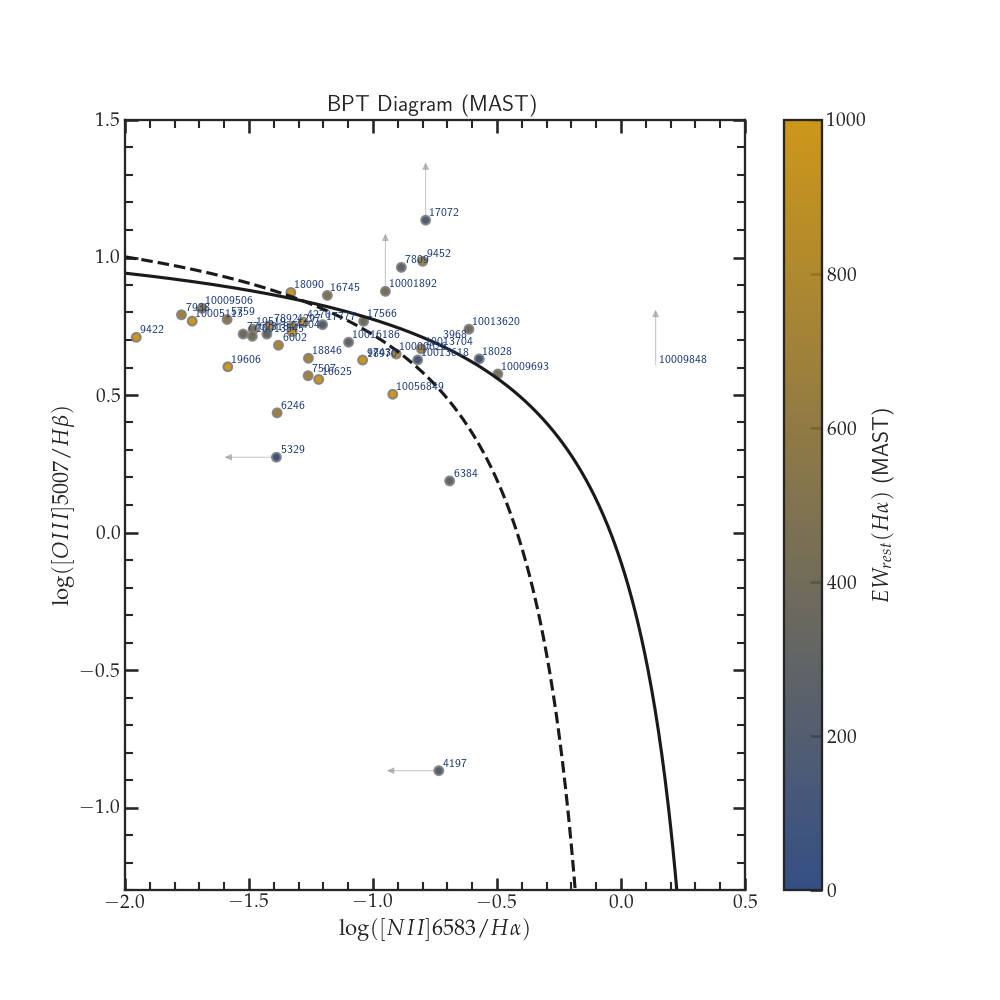

In [18]:
plt_bpt(source='MAST', labels=True, arrows=True, show=True)